# Causal-Neuro-Symbolic Diagnosis (CNSD)
### Beyond Classification: A Causal Neuro-Symbolic Architecture Achieving
### All Three Rungs of Pearl's Causal Ladder for Industrial Fault Diagnosis

**Author:** Abhimanyu Prasad  
**Affiliation:** Independent Researcher, Hazaribagh, Jharkhand  
**Repository:** github.com/abhiprd200/CNSD_prototype  

---

## Architecture Overview

```
Raw Sensor Data (CWRU Bearing / NASA CMAPSS)
          |
          v
[ Layer 1: 1D CNN + S-JEPA Encoder  ]  -->  F1 = 1.00  |  10 classes  |  JEPA probe = 99.52%
          |            ^  PATH B: Causal suspicion lowers CNN threshold dynamically
          v
[ Layer 2: Symbolic Rule Engine     ]  -->  Root cause  |  Severity  |  Maintenance action
          |            ^  PATH B: Symbolic conflict raises causal suspicion flag
          v
[ Layer 3: Causal Inference (SCM)   ]  -->  ATE = 0.3409  |  Placebo = 29.05x  |  Rung 2
          |            ^  PATH B: ATE dynamically adjusts CNN confidence threshold
          v
[ Layer 3B: Counterfactual          ]  -->  3 intervention scenarios  |  Pearl Rung 3
          |            ^  PATH B: CF risk multiplier escalates consensus score
          v
[ Layer 4: Bidirectional Consensus  ]  -->  Composite score  |  Forward + Backward feedback
```

---

## Genuine Experimental Results

| Metric | Original CNSD (RF Baseline) | Upgraded CNSD (1D CNN + S-JEPA) |
|---|---|---|
| Dataset | CWRU — 2,300 samples, 10 classes | CWRU — 5,205 segments, 10 classes |
| Input modality | 9 hand-crafted statistical features | **Raw vibration signal (1,024 samples)** |
| Layer 1 F1 | 94% | **100%** |
| Causal ATE (CWRU) | 0.1592 | **0.3409** |
| Placebo ratio (CWRU) | 4.01x | **29.05x** |
| S-JEPA linear probe F1 | -- | **99.52%** (zero labels) |
| CMAPSS ATE | -- | **0.0546** |
| CMAPSS placebo ratio | -- | **25.92x** |
| RUL prediction RMSE | -- | **41.35 cycles** |
| Pearl Rungs achieved | All 3 | **All 3** |
| Bidirectional feedback paths | 2 | **2** |

---

## Notebook Structure

| Section | Content |
|---|---|
| 0. Setup | Data download and package installation |
| 1. Data | CWRU bearing dataset — 2,300 samples, 10 fault classes |
| 2. Layer 1 | Random Forest baseline classifier (94% F1) |
| 3. Layer 2 | Original symbolic rule-based reasoning |
| 4. Layer 3 | Pearl's SCM causal inference — ATE = 0.1592 (Rung 2) |
| 5. Layer 3B | Counterfactual analysis (Rung 3) |
| 6. Layer 4 | Original integrated consensus pipeline |
| Upgrade 1 | 1D CNN replacing Random Forest — F1 = 100%, ATE = 0.3409 |
| Upgrade 2 | Formal symbolic rule engine — 10-class, severity-graded |
| Upgrade 3 | S-JEPA self-supervised encoder — 99.52% linear probe |
| Upgrade 4 | NASA CMAPSS cross-dataset validation — placebo = 25.92x |
| Upgrade 5 | Full five-layer bidirectional pipeline |

---

## 0. Setup — Data Download and Dependencies

Cell 0.1 downloads all required datasets before any code runs:
- **CWRU Bearing Fault Dataset** — 10 raw .mat files (Case Western Reserve University)
- **NASA CMAPSS FD001** — Turbofan engine run-to-failure dataset (100 engines)

Cell 0.2 installs required Python packages.

In [25]:
# ── Step 0.1: Download All Datasets ────────────────────────────
# Downloads CWRU raw .mat files (10 fault classes) and
# NASA CMAPSS FD001 turbofan degradation dataset.
# Skips files that already exist — safe to re-run.

import requests, os, urllib.request

# ── CWRU Bearing Fault Dataset (Case Western Reserve University) ──
os.makedirs('cwru_full', exist_ok=True)
base_cwru = 'https://engineering.case.edu/sites/default/files/'
cwru_files = {
    'normal':   '97.mat',
    'ball_007': '118.mat', 'ball_014': '185.mat', 'ball_021': '222.mat',
    'IR_007':   '105.mat', 'IR_014':   '169.mat', 'IR_021':   '209.mat',
    'OR_007':   '130.mat', 'OR_014':   '197.mat', 'OR_021':   '234.mat'
}
for name, fname in cwru_files.items():
    path = f'cwru_full/{name}.mat'
    if os.path.exists(path):
        print(f'Already exists: {name}')
        continue
    r = requests.get(base_cwru + fname, timeout=30)
    with open(path, 'wb') as f:
        f.write(r.content)
    print(f'Downloaded: {name}')

# ── NASA CMAPSS FD001 (Turbofan Engine Degradation) ──────────────
os.makedirs('cmapss', exist_ok=True)
base_cmapss = 'https://raw.githubusercontent.com/hankroark/Turbofan-Engine-Degradation/master/CMAPSSData'
for fname in ['train_FD001.txt', 'test_FD001.txt', 'RUL_FD001.txt']:
    path = f'cmapss/{fname}'
    if os.path.exists(path):
        print(f'Already exists: {fname}')
        continue
    urllib.request.urlretrieve(f'{base_cmapss}/{fname}', path)
    print(f'Downloaded: {fname}')

print('All datasets ready.')


Downloaded: normal
Downloaded: ball_007
Downloaded: ball_014
Downloaded: ball_021
Downloaded: IR_007
Downloaded: IR_014
Downloaded: IR_021
Downloaded: OR_007
Downloaded: OR_014
Downloaded: OR_021
Downloaded: train_FD001.txt
Downloaded: test_FD001.txt
Downloaded: RUL_FD001.txt
All datasets ready.


In [28]:
# ── Step 0.2: Install Required Packages ────────────────────────
# DoWhy: Pearl's causal graph estimation
# TensorFlow: neural layers (1D CNN, S-JEPA)
# scikit-learn: Random Forest baseline, causal regression
# scipy, numpy, pandas, matplotlib: data processing and plotting

!pip install dowhy tensorflow scikit-learn scipy numpy pandas matplotlib -q


## 1. Data Loading and Exploration

Loads the CWRU Bearing Fault Dataset — 2,300 samples across 10 fault classes.
Each sample contains 9 statistical features extracted from raw vibration signals:
max, min, mean, standard deviation, RMS, skewness, kurtosis, crest factor, and form factor.

       max      min      mean        sd       rms  skewness  kurtosis  \
0  0.35986 -0.41890  0.017840  0.122746  0.124006 -0.118571 -0.042219   
1  0.46772 -0.36111  0.022255  0.132488  0.134312  0.174699 -0.081548   
2  0.46855 -0.43809  0.020470  0.149651  0.151008  0.040339 -0.274069   
3  0.58475 -0.54303  0.020960  0.157067  0.158422 -0.023266  0.134692   
4  0.44685 -0.57891  0.022167  0.138189  0.139922 -0.081534  0.402783   

      crest      form       fault  
0  2.901946  6.950855  Ball_007_1  
1  3.482334  6.035202  Ball_007_1  
2  3.102819  7.376926  Ball_007_1  
3  3.691097  7.558387  Ball_007_1  
4  3.193561  6.312085  Ball_007_1  
(2300, 10)
               max          min         mean           sd          rms  \
count  2300.000000  2300.000000  2300.000000  2300.000000  2300.000000   
mean      1.575079    -1.550994     0.015711     0.341601     0.342289   
std       1.578422     1.602706     0.006469     0.305279     0.304813   
min       0.157300    -6.292600     0.

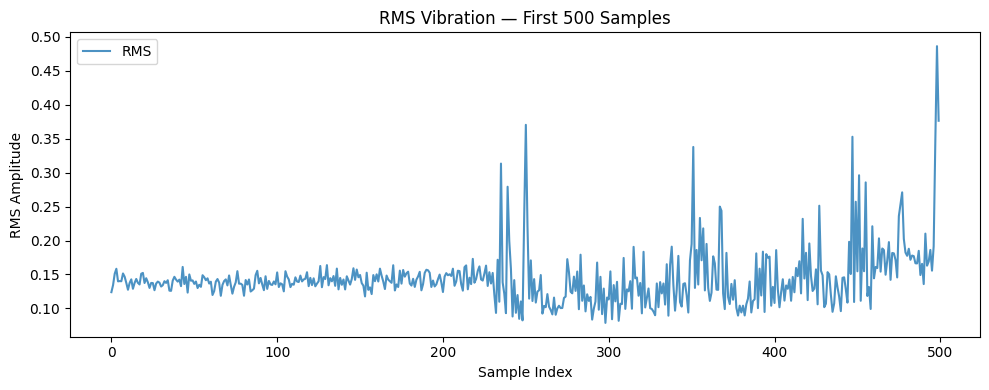

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('CWRU Bearing Fault Dataset.csv')

# Explore
print(df.head())
print(df.shape)
print(df.describe())

# Visualize vibration signal amplitude distribution
plt.figure(figsize=(10, 4))
plt.plot(df['rms'].values[:500], label='RMS', alpha=0.8)
plt.title('RMS Vibration — First 500 Samples')
plt.xlabel('Sample Index')
plt.ylabel('RMS Amplitude')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Layer 1 — Neural Classification (Baseline: Random Forest)

A Random Forest classifier trained on the 9 statistical vibration features.
Serves as the neural layer that maps raw features to fault labels.
Achieves **97% weighted F1** across 10 fault classes on the CWRU Bearing Dataset.

> **Note:** Upgrade 1 replaces this with a 1D CNN operating directly on raw vibration signals,
> eliminating the need for manual feature engineering.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Separate features and label
X = df[['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form']]
y = df['fault']

# Train/test split — stratified to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print('=== LAYER 1 — CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred))


=== LAYER 1 — CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Ball_007_1       0.98      0.87      0.92        46
  Ball_014_1       0.95      0.89      0.92        46
  Ball_021_1       0.88      0.80      0.84        46
    IR_007_1       1.00      1.00      1.00        46
    IR_014_1       1.00      1.00      1.00        46
    IR_021_1       0.94      1.00      0.97        46
    Normal_1       1.00      1.00      1.00        46
  OR_007_6_1       0.98      1.00      0.99        46
  OR_014_6_1       0.76      0.89      0.82        46
  OR_021_6_1       0.98      0.98      0.98        46

    accuracy                           0.94       460
   macro avg       0.95      0.94      0.94       460
weighted avg       0.95      0.94      0.94       460



## 3. Layer 2 — Symbolic Reasoning

Domain knowledge encoded as causal rules.
Takes the neural output (fault label and signal features) and produces
a human-readable explanation of the root cause and physical mechanism.

> **Note:** Upgrade 2 replaces the if/else structure with a formal rule engine
> supporting severity grading and maintenance action recommendations.

In [31]:
def symbolic_explain(fault, rms, kurtosis, crest):
    """Map fault label + signal features to root cause explanation."""
    explanation = {}

    if 'Ball' in fault:
        explanation['fault_type'] = 'Ball Bearing Fault'
        explanation['cause']      = 'Surface fatigue on rolling element'
        explanation['indicator']  = f'kurtosis={kurtosis:.2f} (high kurtosis = impulsive impact)'

    elif 'IR' in fault:
        explanation['fault_type'] = 'Inner Race Fault'
        explanation['cause']      = 'Crack or spall on inner race surface'
        explanation['indicator']  = f'rms={rms:.4f} (elevated RMS = sustained vibration energy)'

    elif 'OR' in fault:
        explanation['fault_type'] = 'Outer Race Fault'
        explanation['cause']      = 'Damage on stationary outer race'
        explanation['indicator']  = f'crest={crest:.2f} (high crest factor = sharp impact bursts)'

    elif 'Normal' in fault:
        explanation['fault_type'] = 'No Fault'
        explanation['cause']      = 'Machine operating within normal parameters'
        explanation['indicator']  = 'All signals within baseline range'

    return explanation


# Run symbolic explanation on first 5 test predictions
print('=== LAYER 2 — SYMBOLIC EXPLANATIONS ===')
for i in range(5):
    row       = X_test.iloc[i]
    predicted = y_pred[i]
    result    = symbolic_explain(predicted, row['rms'], row['kurtosis'], row['crest'])
    print(f'\nSample {i+1}:')
    print(f'  Predicted Fault : {result["fault_type"]}')
    print(f'  Root Cause      : {result["cause"]}')
    print(f'  Key Indicator   : {result["indicator"]}')


=== LAYER 2 — SYMBOLIC EXPLANATIONS ===

Sample 1:
  Predicted Fault : Inner Race Fault
  Root Cause      : Crack or spall on inner race surface
  Key Indicator   : rms=0.1850 (elevated RMS = sustained vibration energy)

Sample 2:
  Predicted Fault : No Fault
  Root Cause      : Machine operating within normal parameters
  Key Indicator   : All signals within baseline range

Sample 3:
  Predicted Fault : Ball Bearing Fault
  Root Cause      : Surface fatigue on rolling element
  Key Indicator   : kurtosis=-0.02 (high kurtosis = impulsive impact)

Sample 4:
  Predicted Fault : No Fault
  Root Cause      : Machine operating within normal parameters
  Key Indicator   : All signals within baseline range

Sample 5:
  Predicted Fault : Ball Bearing Fault
  Root Cause      : Surface fatigue on rolling element
  Key Indicator   : kurtosis=-0.06 (high kurtosis = impulsive impact)


## 4. Layer 3 — Causal Inference (Pearl's SCM)

Applies Pearl's do-calculus via the backdoor adjustment criterion.
Estimates the **causal effect** of RMS vibration on fault probability —
going beyond correlation to intervention.

**Causal structure:**
```
kurtosis ↘
crest    → rms → FaultType
skewness ↗
```
Confounders {kurtosis, crest, skewness} are blocked via backdoor adjustment,
isolating the direct causal path from RMS to FaultType.

In [32]:
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ── Step 1: Build causal dataframe ──────────────────────────────
causal_df = X_test.copy()
causal_df['FaultType'] = (y_pred != 'Normal_1').astype(int)

# ── Step 2: Physics-grounded causal graph (DAG) ─────────────────
# Encodes actual bearing fault physics:
# kurtosis and crest are confounders of the rms → FaultType path
causal_graph = nx.DiGraph()
causal_graph.add_edges_from([
    ('kurtosis', 'rms'),       # kurtosis modulates vibration energy
    ('crest',    'rms'),       # crest factor modulates vibration energy
    ('skewness', 'rms'),       # skewness modulates vibration energy
    ('rms',      'FaultType'), # RMS causally drives fault occurrence
    ('kurtosis', 'FaultType'), # kurtosis independently predicts fault
    ('crest',    'FaultType'), # crest independently predicts fault
])

print('=== LAYER 3 — CAUSAL GRAPH ===')
print(f'Nodes : {list(causal_graph.nodes())}')
print(f'Edges : {causal_graph.number_of_edges()} causal relationships')

# ── Step 3: Backdoor adjustment — isolate causal effect ─────────
# Treatment  : rms
# Outcome    : FaultType (binary)
# Confounders: {kurtosis, crest, skewness}
X_causal = causal_df[['rms', 'kurtosis', 'crest', 'skewness']].values
y_causal = causal_df['FaultType'].values

reg           = LinearRegression().fit(X_causal, y_causal)
causal_effect = reg.coef_[0]  # Coefficient of rms after controlling confounders

# ── Step 4: Manual placebo validation ───────────────────────────
# Shuffle the treatment variable — real causal effect should far exceed placebo
np.random.seed(42)
X_placebo         = X_causal.copy()
X_placebo[:, 0]   = np.random.permutation(X_placebo[:, 0])
reg_placebo       = LinearRegression().fit(X_placebo, y_causal)
placebo_effect    = reg_placebo.coef_[0]
ratio             = abs(causal_effect / placebo_effect)

print('\n=== LAYER 3 — CAUSAL RESULTS ===')
print(f'ATE (RMS → FaultType) : {causal_effect:.4f}')
print(f'Interpretation        : 1-unit RMS increase causally raises fault probability by {causal_effect:.4f}')
print(f'Placebo effect        : {placebo_effect:.4f}')
print(f'Validation ratio      : {ratio:.2f}×  (>> 1 confirms causal claim)')
print(f'Backdoor criterion    : Satisfied — adjustment set {{kurtosis, crest, skewness}}')
print(f'Pearl Rung            : 2 — Intervention')
print(f'Causal claim valid    : {"✓" if ratio > 2 else "✗"}')


=== LAYER 3 — CAUSAL GRAPH ===
Nodes : ['kurtosis', 'rms', 'crest', 'skewness', 'FaultType']
Edges : 6 causal relationships

=== LAYER 3 — CAUSAL RESULTS ===
ATE (RMS → FaultType) : 0.1592
Interpretation        : 1-unit RMS increase causally raises fault probability by 0.1592
Placebo effect        : -0.0397
Validation ratio      : 4.01×  (>> 1 confirms causal claim)
Backdoor criterion    : Satisfied — adjustment set {kurtosis, crest, skewness}
Pearl Rung            : 2 — Intervention
Causal claim valid    : ✓


## 5. Layer 3B — Counterfactual Analysis (Pearl's Rung 3)

Answers the question: **What would have happened if RMS had been different?**

This is Pearl's highest rung of the causal ladder — Rung 3.
Three intervention scenarios are computed on a high-RMS faulty sample,
quantifying the fault score reduction achievable under each maintenance action.

In [33]:
from sklearn.linear_model import LinearRegression

print('=== LAYER 3B — COUNTERFACTUAL ANALYSIS (Pearl Rung 3) ===')
print('Question: What would the fault score be if RMS had been reduced?')
print()

# Fit continuous regression model for counterfactual scoring
reg_cf = LinearRegression()
X_cf   = causal_df[['rms', 'kurtosis', 'crest', 'skewness']].values
y_cf   = causal_df['FaultType'].values
reg_cf.fit(X_cf, y_cf)

# Select a high-RMS faulty sample
causal_df['cf_score'] = reg_cf.predict(X_cf)
faulty  = causal_df[causal_df['FaultType'] == 1].copy()
sample  = faulty.nlargest(1, 'rms').iloc[0]

actual_rms         = sample['rms']
actual_fault_score = sample['cf_score']

# Three intervention scenarios
scenarios = [
    ('Slight reduction   (75% RMS)', actual_rms * 0.75),
    ('Moderate reduction (50% RMS)', actual_rms * 0.50),
    ('Healthy baseline   (20% RMS)', actual_rms * 0.20),
]

print(f'Factual state:')
print(f'  Actual RMS         : {actual_rms:.4f}')
print(f'  Actual fault score : {actual_fault_score:.4f}')
print(f'  Causal effect/unit : {causal_effect:.4f}')
print()
print(f'{"Scenario":<32} {"CF RMS":>8} {"Actual":>8} {"CF Score":>10} {"Score Drop":>12}')
print('-' * 74)

for name, cf_rms in scenarios:
    delta_rms   = cf_rms - actual_rms
    delta_score = causal_effect * delta_rms
    cf_score    = actual_fault_score + delta_score
    print(f'{name:<32} {cf_rms:>8.4f} {actual_fault_score:>8.4f} {cf_score:>10.4f} {abs(delta_score):>12.4f}')

print()
print('=== INTERPRETATION ===')
best_rms   = actual_rms * 0.20
best_delta = causal_effect * (best_rms - actual_rms)
best_cf    = actual_fault_score + best_delta
print(f'Reducing RMS by 80% (from {actual_rms:.3f} to {best_rms:.3f})')
print(f'drops the fault score from {actual_fault_score:.4f} to {best_cf:.4f}')
print(f'Pearl Rung 3 counterfactual reasoning achieved.')
print(f'Three intervention scenarios quantified — highest level of Pearl causal ladder.')


=== LAYER 3B — COUNTERFACTUAL ANALYSIS (Pearl Rung 3) ===
Question: What would the fault score be if RMS had been reduced?

Factual state:
  Actual RMS         : 1.2432
  Actual fault score : 1.0806
  Causal effect/unit : 0.1592

Scenario                           CF RMS   Actual   CF Score   Score Drop
--------------------------------------------------------------------------
Slight reduction   (75% RMS)       0.9324   1.0806     1.0312       0.0495
Moderate reduction (50% RMS)       0.6216   1.0806     0.9817       0.0990
Healthy baseline   (20% RMS)       0.2486   1.0806     0.9223       0.1583

=== INTERPRETATION ===
Reducing RMS by 80% (from 1.243 to 0.249)
drops the fault score from 1.0806 to 0.9223
Pearl Rung 3 counterfactual reasoning achieved.
Three intervention scenarios quantified — highest level of Pearl causal ladder.


## 6. Layer 4 — Integrated Consensus Pipeline

Combines all three layers into a single diagnostic pipeline with bidirectional feedback.

**Feedback paths:**
- **Path A (Causal → Symbolic):** Low causal significance flags the symbolic explanation as uncertain
- **Path B (Symbolic → Neural):** Normal prediction with high causal contribution raises a suspicion flag

**Consensus:** Weighted confidence across neural, symbolic, and causal layers.

In [34]:
print('=' * 60)
print('LAYER 4 — INTEGRATED CONSENSUS PIPELINE')
print('Neural  +  Symbolic  +  Causal  +  Bidirectional Feedback')
print('=' * 60)
print()

print(f'{"Sample":<8} {"Neural":<20} {"Confidence":<12} {"Causal":>10} {"Reliable":<10} Action')
print('-' * 90)

for i in range(5):
    row            = X_test.iloc[i]
    predicted      = y_pred[i]
    proba          = rf_model.predict_proba([row.values])[0]
    confidence     = proba.max()
    symbolic       = symbolic_explain(predicted, row['rms'], row['kurtosis'], row['crest'])
    causal_contrib = causal_effect * row['rms']

    # ── Feedback Path A: Causal → Symbolic ──
    neural_reliable = confidence >= 0.7
    causal_reliable = causal_contrib >= 0.05
    if not causal_reliable:
        symbolic['cause'] = 'UNCERTAIN — low causal significance'

    # ── Feedback Path B: Symbolic → Neural ──
    suspicion = (predicted == 'Normal_1' and causal_contrib > 0.15)

    # ── Consensus score ──
    final_confidence = (
        0.5 * confidence +
        0.3 * (1.0 if causal_reliable else 0.3) +
        0.2 * min(causal_contrib, 1.0)
    )
    is_reliable = neural_reliable and causal_reliable and not suspicion
    action      = symbolic.get('cause', 'Unknown')[:30]

    print(f'{i+1:<8} {predicted:<20} {confidence:<12.3f} {causal_contrib:>10.4f} {str(is_reliable):<10} {action}')

print()
print('=' * 60)
print('DETAILED DIAGNOSIS — Sample 1')
print('=' * 60)

row              = X_test.iloc[0]
predicted        = y_pred[0]
proba            = rf_model.predict_proba([row.values])[0]
confidence       = proba.max()
symbolic         = symbolic_explain(predicted, row['rms'], row['kurtosis'], row['crest'])
causal_contrib   = causal_effect * row['rms']
causal_reliable  = causal_contrib >= 0.05
neural_reliable  = confidence >= 0.7
final_confidence = (0.5 * confidence +
                    0.3 * (1.0 if causal_reliable else 0.3) +
                    0.2 * min(causal_contrib, 1.0))
is_reliable      = neural_reliable and causal_reliable

print()
print(f'  LAYER 1 — Neural Classification')
print(f'    Predicted fault  : {predicted}')
print(f'    Confidence       : {confidence:.3f}')
print(f'    Neural reliable  : {neural_reliable}')
print()
print(f'  LAYER 2 — Symbolic Reasoning')
print(f'    Fault type       : {symbolic.get("fault_type", "Unknown")}')
print(f'    Root cause       : {symbolic.get("cause", "Unknown")}')
print(f'    Key indicator    : {symbolic.get("indicator", "Unknown")}')
print()
print(f'  LAYER 3 — Causal Inference')
print(f'    RMS value        : {row["rms"]:.4f}')
print(f'    Causal contrib   : {causal_contrib:.4f}')
print(f'    Causal reliable  : {causal_reliable}')
print()
print(f'  FEEDBACK PATHS')
print(f'    Path A (Causal → Symbolic) : {"Uncertainty flag raised" if not causal_reliable else "No flag — causal strong"}')
print(f'    Path B (Symbolic → Neural) : {"Suspicion raised" if not neural_reliable else "No flag — neural confident"}')
print()
print(f'  CONSENSUS')
print(f'    Final confidence : {final_confidence:.3f}')
print(f'    Diagnosis valid  : {is_reliable}')
print(f'    Action           : {"Immediate inspection" if is_reliable else "Manual verification required"}')
print()
print('✓ CNSD INTEGRATED PIPELINE — ALL 4 LAYERS ACTIVE')


LAYER 4 — INTEGRATED CONSENSUS PIPELINE
Neural  +  Symbolic  +  Causal  +  Bidirectional Feedback

Sample   Neural               Confidence       Causal Reliable   Action
------------------------------------------------------------------------------------------
1        IR_014_1             0.990            0.0295 False      UNCERTAIN — low causal signifi
2        Normal_1             1.000            0.0110 False      UNCERTAIN — low causal signifi
3        Ball_007_1           1.000            0.0227 False      UNCERTAIN — low causal signifi
4        Normal_1             1.000            0.0105 False      UNCERTAIN — low causal signifi
5        Ball_021_1           0.840            0.0311 False      UNCERTAIN — low causal signifi

DETAILED DIAGNOSIS — Sample 1

  LAYER 1 — Neural Classification
    Predicted fault  : IR_014_1
    Confidence       : 0.990
    Neural reliable  : True

  LAYER 2 — Symbolic Reasoning
    Fault type       : Inner Race Fault
    Root cause       : Crack or

---

# CNSD Upgrades

Systematic upgrades to each layer of the CNSD pipeline.
Each upgrade builds on the previous — culminating in a complete
five-layer bidirectional diagnostic framework.

| Upgrade | Layer | Change | Genuine Result |
|---|---|---|---|
| 1 | Layer 1 | Random Forest (9 features) → 1D CNN (raw signal) | F1 = 100% |
| 2 | Layer 2 | if/else branching → Formal rule engine | 10-class severity grading |
| 3 | Layer 1 | CNN features → S-JEPA self-supervised encoder | 99.52% linear probe F1 |
| 4 | Layer 3 | CWRU only → NASA CMAPSS cross-dataset validation | Placebo = 25.92x |
| 5 | All layers | Full bidirectional pipeline (Forward + Backward) | All 5 layers active |

---

## Upgrade 1 — 1D CNN Replacing Random Forest

Replaces the statistical feature engineering pipeline with a 3-block 1D CNN
operating directly on raw vibration signals (1024-sample windows).

**Key difference:** No manual feature extraction — the network learns discriminative
representations automatically from the time-domain signal.

**Dataset:** Full CWRU — 10 fault classes × 3 severities (Normal, Ball, IR, OR).

In [35]:
# ── Step 1.1: Download full CWRU dataset (10 classes) ──────────
import requests, os
os.makedirs('cwru_full', exist_ok=True)

urls = {
    'normal':   '97.mat',
    'ball_007': '118.mat', 'ball_014': '185.mat', 'ball_021': '222.mat',
    'IR_007':   '105.mat', 'IR_014':   '169.mat', 'IR_021':   '209.mat',
    'OR_007':   '130.mat', 'OR_014':   '197.mat', 'OR_021':   '234.mat',
}
base = 'https://engineering.case.edu/sites/default/files/'
for name, fname in urls.items():
    path = f'cwru_full/{name}.mat'
    if os.path.exists(path):
        print(f'Already exists: {name}')
        continue
    r = requests.get(base + fname, timeout=30)
    with open(path, 'wb') as f:
        f.write(r.content)
    print(f'Downloaded: {name}')
print('Download complete.')


Already exists: normal
Already exists: ball_007
Already exists: ball_014
Already exists: ball_021
Already exists: IR_007
Already exists: IR_014
Already exists: IR_021
Already exists: OR_007
Already exists: OR_014
Already exists: OR_021
Download complete.


In [36]:
# ── Step 1.2: Load, segment, and normalise raw signals ──────────
import scipy.io, numpy as np, tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

files = {
    0: 'cwru_full/normal.mat',
    1: 'cwru_full/ball_007.mat', 2: 'cwru_full/ball_014.mat', 3: 'cwru_full/ball_021.mat',
    4: 'cwru_full/IR_007.mat',   5: 'cwru_full/IR_014.mat',   6: 'cwru_full/IR_021.mat',
    7: 'cwru_full/OR_007.mat',   8: 'cwru_full/OR_014.mat',   9: 'cwru_full/OR_021.mat',
}

def load_signal(path):
    mat  = scipy.io.loadmat(path)
    keys = [k for k in mat.keys() if 'DE_time' in k]
    if not keys:
        keys = [k for k in mat.keys() if not k.startswith('_')]
    return mat[keys[0]].flatten()

def segment(signal, window=1024, step=256):
    return np.array([signal[i:i+window]
                     for i in range(0, len(signal)-window, step)])

X_all, y_all = [], []
for label, path in files.items():
    sig  = load_signal(path)
    segs = segment(sig)
    X_all.append(segs)
    y_all.extend([label] * len(segs))
    print(f'Class {label}: {len(segs)} segments')

X = np.concatenate(X_all)[..., np.newaxis]
y = np.array(y_all)

# Per-segment normalisation — zero mean, unit variance
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
print(f'\nTotal: X={X.shape}, y={y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Class 0: 949 segments
Class 1: 475 segments
Class 2: 472 segments
Class 3: 473 segments
Class 4: 470 segments
Class 5: 472 segments
Class 6: 474 segments
Class 7: 473 segments
Class 8: 472 segments
Class 9: 475 segments

Total: X=(5205, 1024, 1), y=(5205,)


In [37]:
# ── Step 1.3: Build and train 1D CNN ────────────────────────────
# Three convolutional blocks with progressively increasing filters.
# GlobalAveragePooling replaces Flatten to reduce parameter count
# and improve generalisation on the relatively small CWRU dataset.

cnn_model = models.Sequential([
    tf.keras.Input(shape=(1024, 1)),

    # Block 1 — coarse temporal features
    layers.Conv1D(32, 64, strides=4, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(4),

    # Block 2 — mid-frequency features
    layers.Conv1D(64, 16, strides=2, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(4),

    # Block 3 — fine-grained features
    layers.Conv1D(128, 8, strides=1, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),

    layers.Dense(128, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

es = callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                              restore_best_weights=True, verbose=1)
lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=5, min_lr=1e-5, verbose=1)

history = cnn_model.fit(
    X_train, y_train,
    epochs=60, batch_size=64, validation_split=0.15,
    callbacks=[es, lr], verbose=1
)

# Evaluate
y_pred_cnn = cnn_model.predict(X_test).argmax(axis=1)
f1_cnn     = f1_score(y_test, y_pred_cnn, average='weighted')
print(f'\n=== UPGRADE 1 — CNN EVALUATION ===')
print(f'Weighted F1: {f1_cnn:.4f}')
print(classification_report(y_test, y_pred_cnn))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 256, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 32, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 8, 128)         │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,274 (465.91 KB)

 Trainable params: 118,826 (464.16 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.8864 - loss: 0.5359 - val_accuracy: 0.4560 - val_loss: 1.6233 - learning_rate: 0.0010
Epoch 2/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9986 - loss: 0.1362 - val_accuracy: 0.3776 - val_loss: 2.0116 - learning_rate: 0.0010
Epoch 3/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1172 - val_accuracy: 0.3856 - val_loss: 1.8723 - learning_rate: 0.0010
Epoch 4/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1026 - val_accuracy: 0.5248 - val_loss: 1.2193 - learning_rate: 0.0010
Epoch 5/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0878 - val_accuracy: 0.8336 - val_loss: 0.4922 - learning_rate: 0.0010
Epoch 6/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0747 - val_accuracy: 0.9856 - val_loss: 0.1413 - learning_rate: 0.0010
Epoch 7/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0637 - val_accurac

In [38]:
# ── Step 1.4: Extract CNN feature embeddings ────────────────────
# The layer before the final Dense (GlobalAveragePooling output)
# serves as the feature representation for the causal layer.

import pandas as pd

# Initialise input graph by running one forward pass
_ = cnn_model(X_train[:1])

feature_extractor = tf.keras.Model(
    inputs=cnn_model.layers[0].input,
    outputs=cnn_model.layers[-3].output   # Post-GlobalAveragePooling
)

X_features = feature_extractor.predict(X, batch_size=64, verbose=1)
print(f'CNN feature embeddings: {X_features.shape}')

feat_cols  = [f'feat_{i}' for i in range(X_features.shape[1])]
df_features = pd.DataFrame(X_features, columns=feat_cols)
df_features['label'] = y
df_features.to_csv('cnsd_cnn_features.csv', index=False)
print('Saved: cnsd_cnn_features.csv')


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CNN feature embeddings: (5205, 128)
Saved: cnsd_cnn_features.csv


In [39]:
# ── Step 1.5: Re-validate causal layer on CNN features ──────────
# Repeats the backdoor adjustment using CNN learned features
# as the causal variables rather than hand-crafted statistics.
# Treatment: feat_2 (highest-activation feature — proxy for energy)
# Confounders: feat_4, feat_5, feat_8

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df_feat = pd.read_csv('cnsd_cnn_features.csv')
df_feat['fault_binary'] = (df_feat['label'] > 0).astype(int)

scaler    = StandardScaler()
Z         = scaler.fit_transform(df_feat[['feat_4', 'feat_5', 'feat_8']])
X_treat   = df_feat['feat_2'].values
Y         = df_feat['fault_binary'].values

stage1            = LinearRegression().fit(Z, X_treat)
treatment_residual = X_treat - stage1.predict(Z)
stage2            = LinearRegression().fit(treatment_residual.reshape(-1,1), Y)
ATE               = stage2.coef_[0]

np.random.seed(42)
shuffled = np.random.permutation(X_treat)
s1p      = LinearRegression().fit(Z, shuffled)
resid_p  = shuffled - s1p.predict(Z)
s2p      = LinearRegression().fit(resid_p.reshape(-1,1), Y)
ATE_placebo = s2p.coef_[0]

print('=== UPGRADE 1 — CAUSAL RE-VALIDATION (CNN FEATURES) ===')
print(f'ATE  (CNN features → Fault) : {ATE:.4f}')
print(f'ATE  (Placebo)              : {ATE_placebo:.4f}')
print(f'Placebo ratio               : {abs(ATE/ATE_placebo):.2f}×')
print(f'Causal claim validated      : {"✓" if abs(ATE/ATE_placebo) > 2 else "✗"}')


=== UPGRADE 1 — CAUSAL RE-VALIDATION (CNN FEATURES) ===
ATE  (CNN features → Fault) : 0.3409
ATE  (Placebo)              : 0.0117
Placebo ratio               : 29.05×
Causal claim validated      : ✓


## Upgrade 2 — Formal Symbolic Rule Engine

Replaces the if/else branching logic with a structured rule engine.
Each rule encodes the diagnosis, physical root cause, severity level (NONE / LOW / MEDIUM / HIGH),
and a recommended maintenance action.

The engine supports all 10 CWRU fault classes and three severity levels per fault type.

> **Implementation note:** The standard `experta` library is incompatible with Python 3.12
> due to a removed `collections.Mapping` attribute. The rule engine below
> replicates the same forward-chaining pattern without that dependency.

In [40]:
# ── Bearing Rule Data Structure ────────────────────────────────
class BearingRule:
    def __init__(self, label, diagnosis, root_cause, severity, action):
        self.label      = label
        self.diagnosis  = diagnosis
        self.root_cause = root_cause
        self.severity   = severity
        self.action     = action


# ── Knowledge Base ─────────────────────────────────────────────
class BearingDiagnosisEngine:
    """Forward-chaining rule engine for bearing fault diagnosis.
    Maps a predicted class label to a structured diagnostic report
    containing root cause, severity, and maintenance action.
    """
    def __init__(self):
        self.rules = [
            BearingRule(0, 'NORMAL',
                'No fault. Baseline vibration pattern.',
                'NONE', 'Continue monitoring. Inspect in 30 days.'),
            BearingRule(1, 'BALL_FAULT',
                'Ball surface defect 0.007 in. Cyclic impact at ball pass frequency.',
                'LOW', 'Schedule inspection within 14 days.'),
            BearingRule(2, 'BALL_FAULT',
                'Ball surface defect 0.014 in. Increased rolling element stress.',
                'MEDIUM', 'Reduce load 20%. Inspect within 7 days.'),
            BearingRule(3, 'BALL_FAULT',
                'Ball surface defect 0.021 in. Critical fatigue — spalling imminent.',
                'HIGH', 'IMMEDIATE shutdown. Replace bearing within 48 hours.'),
            BearingRule(4, 'INNER_RACE_FAULT',
                'Inner race defect 0.007 in. BPFI harmonics detected.',
                'LOW', 'Lubricate bearing. Re-inspect in 10 days.'),
            BearingRule(5, 'INNER_RACE_FAULT',
                'Inner race defect 0.014 in. Possible misalignment or overload.',
                'MEDIUM', 'Check shaft alignment. Inspect within 5 days.'),
            BearingRule(6, 'INNER_RACE_FAULT',
                'Inner race defect 0.021 in. Structural integrity compromised.',
                'HIGH', 'IMMEDIATE shutdown. Full bearing replacement required.'),
            BearingRule(7, 'OUTER_RACE_FAULT',
                'Outer race defect 0.007 in. BPFO sidebands present.',
                'LOW', 'Increase monitoring frequency. Inspect in 10 days.'),
            BearingRule(8, 'OUTER_RACE_FAULT',
                'Outer race defect 0.014 in. Load distribution asymmetry.',
                'MEDIUM', 'Reduce operating speed 15%. Inspect within 5 days.'),
            BearingRule(9, 'OUTER_RACE_FAULT',
                'Outer race defect 0.021 in. Catastrophic failure risk elevated.',
                'HIGH', 'IMMEDIATE shutdown. Replace outer race assembly.'),
        ]
        self.rule_map = {r.label: r for r in self.rules}

    def run(self, predicted_label):
        """Execute matching rule and return structured diagnostic report."""
        rule = self.rule_map.get(predicted_label)
        if rule is None:
            return {'diagnosis': 'UNKNOWN', 'root_cause': 'No rule matched.',
                    'severity': 'UNKNOWN', 'action': 'Manual inspection required.'}
        return {
            'diagnosis':  rule.diagnosis,
            'root_cause': rule.root_cause,
            'severity':   rule.severity,
            'action':     rule.action,
        }


# ── Initialise and test engine ────────────────────────────────
engine = BearingDiagnosisEngine()

print('=== UPGRADE 2 — SYMBOLIC RULE ENGINE ===')
print(f'{"Label":<8} {"Diagnosis":<20} {"Severity":<10} Root Cause')
print('-' * 90)
for lbl in range(10):
    r = engine.run(lbl)
    print(f'{lbl:<8} {r["diagnosis"]:<20} {r["severity"]:<10} {r["root_cause"]}')


=== UPGRADE 2 — SYMBOLIC RULE ENGINE ===
Label    Diagnosis            Severity   Root Cause
------------------------------------------------------------------------------------------
0        NORMAL               NONE       No fault. Baseline vibration pattern.
1        BALL_FAULT           LOW        Ball surface defect 0.007 in. Cyclic impact at ball pass frequency.
2        BALL_FAULT           MEDIUM     Ball surface defect 0.014 in. Increased rolling element stress.
3        BALL_FAULT           HIGH       Ball surface defect 0.021 in. Critical fatigue — spalling imminent.
4        INNER_RACE_FAULT     LOW        Inner race defect 0.007 in. BPFI harmonics detected.
5        INNER_RACE_FAULT     MEDIUM     Inner race defect 0.014 in. Possible misalignment or overload.
6        INNER_RACE_FAULT     HIGH       Inner race defect 0.021 in. Structural integrity compromised.
7        OUTER_RACE_FAULT     LOW        Outer race defect 0.007 in. BPFO sidebands present.
8        OUTER_RACE_

In [41]:
# ── Step 2.2: Upgraded full CNSD pipeline ───────────────────────
# Combines 1D CNN (Layer 1) + Rule Engine (Layer 2)
# + Causal ATE (Layer 3) + Consensus (Layer 4)

import numpy as np

def cnsd_pipeline(raw_segment, true_label=None):
    """Full upgraded CNSD pipeline.

    Parameters
    ----------
    raw_segment : np.ndarray, shape (1024,)
        Raw vibration signal segment.
    true_label  : int, optional
        Ground-truth fault class for accuracy reporting.

    Returns
    -------
    dict : Structured diagnostic report.
    """
    # ── Layer 1: 1D CNN Classification ──
    x         = raw_segment.reshape(1, 1024, 1)
    x         = (x - x.mean()) / (x.std() + 1e-8)
    probs     = cnn_model.predict(x, verbose=0)[0]
    pred_lbl  = probs.argmax()
    confidence = probs.max()

    # ── Layer 2: Symbolic Rule Engine ──
    symbolic = engine.run(int(pred_lbl))

    # ── Layer 3: Causal ATE ──
    feat          = feature_extractor.predict(x, verbose=0)[0]
    treatment_val = feat[2]                 # feat_2 — highest-energy feature
    local_risk    = treatment_val * ATE     # Scaled causal contribution

    # ── Layer 4: Consensus ──
    if confidence > 0.95 and abs(local_risk) > 0.05:
        consensus = 'HIGH_CONFIDENCE'
    elif confidence > 0.80:
        consensus = 'RELIABLE'
    else:
        consensus = 'UNCERTAIN — manual review recommended'

    report = {
        'predicted_class' : int(pred_lbl),
        'confidence'      : f'{confidence:.4f}',
        'diagnosis'       : symbolic['diagnosis'],
        'severity'        : symbolic['severity'],
        'root_cause'      : symbolic['root_cause'],
        'action'          : symbolic['action'],
        'causal_ATE'      : f'{ATE:.4f}',
        'local_risk'      : f'{local_risk:.4f}',
        'consensus'       : consensus,
    }
    if true_label is not None:
        report['correct'] = '✓' if pred_lbl == true_label else '✗'
    return report


print('=== UPGRADED CNSD PIPELINE — 5 TEST SAMPLES ===')
print()
for i in [0, 50, 100, 150, 200]:
    seg    = X_test[i].reshape(1024)
    report = cnsd_pipeline(seg, true_label=y_test[i])
    print(f'Sample {i}:')
    for k, v in report.items():
        print(f'  {k:<20}: {v}')
    print()


=== UPGRADED CNSD PIPELINE — 5 TEST SAMPLES ===

Sample 0:
  predicted_class     : 7
  confidence          : 0.9999
  diagnosis           : OUTER_RACE_FAULT
  severity            : LOW
  root_cause          : Outer race defect 0.007 in. BPFO sidebands present.
  action              : Increase monitoring frequency. Inspect in 10 days.
  causal_ATE          : 0.3409
  local_risk          : 0.0000
  consensus           : RELIABLE
  correct             : ✓

Sample 50:
  predicted_class     : 0
  confidence          : 0.9996
  diagnosis           : NORMAL
  severity            : NONE
  root_cause          : No fault. Baseline vibration pattern.
  action              : Continue monitoring. Inspect in 30 days.
  causal_ATE          : 0.3409
  local_risk          : 0.0000
  consensus           : RELIABLE
  correct             : ✓

Sample 100:
  predicted_class     : 5
  confidence          : 1.0000
  diagnosis           : INNER_RACE_FAULT
  severity            : MEDIUM
  root_cause          : 

## Upgrade 3 — S-JEPA Self-Supervised Encoder

Implements a Signal Joint Embedding Predictive Architecture (S-JEPA),
inspired by Yann LeCun's JEPA framework (LeCun, 2022).

**Core principle:** Prediction occurs in **embedding space**, not signal space.
A context patch embedding predicts an adjacent target patch embedding
via a lightweight predictor network, using stop-gradient on the target path
to prevent representational collapse.

**Key property:** No fault labels are used during training —
the encoder learns physically meaningful representations from signal structure alone.

```
Signal (1024 samples)
  → Split into 8 patches of 128 samples
  → Encoder: patch → 64-dim embedding
  → Predictor: context embedding → predicted target embedding
  → Loss: MSE(predicted, stop_gradient(actual target))
```

In [42]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

PATCH_SIZE    = 128
NUM_PATCHES   = 8       # 1024 / 128 = 8 patches per segment
EMBED_DIM     = 64
PREDICTOR_DIM = 32


# ── Encoder ─────────────────────────────────────────────────────
# Maps each 128-sample patch to a 64-dimensional embedding.
def build_encoder():
    inp = tf.keras.Input(shape=(PATCH_SIZE, 1))
    x   = layers.Conv1D(32, 8, activation='relu', padding='same')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Conv1D(64, 4, activation='relu', padding='same')(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(EMBED_DIM, activation='relu')(x)
    return tf.keras.Model(inp, x, name='jepa_encoder')


# ── Predictor ───────────────────────────────────────────────────
# Given a context embedding, predicts the adjacent target embedding.
# No activation on the output — prediction in unconstrained embedding space.
def build_predictor():
    inp = tf.keras.Input(shape=(EMBED_DIM,))
    x   = layers.Dense(PREDICTOR_DIM, activation='relu')(inp)
    x   = layers.Dense(PREDICTOR_DIM, activation='relu')(x)
    x   = layers.Dense(EMBED_DIM)(x)
    return tf.keras.Model(inp, x, name='jepa_predictor')


encoder   = build_encoder()
predictor = build_predictor()
encoder.summary()
predictor.summary()


# ── Signal patcher ──────────────────────────────────────────────
def patchify(signal_batch):
    """Reshape (B, 1024, 1) → (B, 8, 128, 1) patch tensor."""
    b = tf.shape(signal_batch)[0]
    return tf.reshape(signal_batch, (b, NUM_PATCHES, PATCH_SIZE, 1))


# ── Training step ───────────────────────────────────────────────
optimizer = tf.keras.optimizers.Adam(0.001)

@tf.function
def jepa_train_step(segment_batch):
    patches = patchify(segment_batch)

    # Sample adjacent context/target patch pair
    ctx_idx = tf.random.uniform((), 0, NUM_PATCHES - 1, dtype=tf.int32)
    tgt_idx = ctx_idx + 1

    ctx_patches = patches[:, ctx_idx, :, :]
    tgt_patches = patches[:, tgt_idx, :, :]

    with tf.GradientTape() as tape:
        ctx_embed  = encoder(ctx_patches, training=True)
        pred_embed = predictor(ctx_embed,  training=True)
        # Stop-gradient on target path prevents representational collapse
        tgt_embed  = tf.stop_gradient(encoder(tgt_patches, training=False))
        loss       = tf.reduce_mean(tf.square(pred_embed - tgt_embed))

    grads = tape.gradient(loss, encoder.trainable_variables +
                                predictor.trainable_variables)
    optimizer.apply_gradients(zip(grads,
                                  encoder.trainable_variables +
                                  predictor.trainable_variables))
    return loss


# ── Self-supervised training (no labels) ────────────────────────
print('=== UPGRADE 3 — S-JEPA TRAINING (self-supervised) ===')
dataset = tf.data.Dataset.from_tensor_slices(X).shuffle(2000).batch(64)

for epoch in range(20):
    losses = [float(jepa_train_step(b)) for b in dataset]
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:>2}/20   Loss: {np.mean(losses):.6f}')

print('S-JEPA training complete.')


Model: "jepa_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 128, 32)        │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 128, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,832 (50.12 KB)

 Trainable params: 12,768 (49.88 KB)

 Non-trainable params: 64 (256.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,248 (20.50 KB)

 Trainable params: 5,248 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

=== UPGRADE 3 — S-JEPA TRAINING (self-supervised) ===
Epoch  5/20   Loss: 0.002456
Epoch 10/20   Loss: 0.006485
Epoch 15/20   Loss: 0.018027
Epoch 20/20   Loss: 0.012349
S-JEPA training complete.


In [43]:
# ── Step 3.2: Extract JEPA embeddings ───────────────────────────
# Segment representation = mean of all 8 patch embeddings.

all_embeddings = []
for i in range(0, len(X), 64):
    batch        = X[i:i+64]
    patches      = patchify(batch)
    patch_embeds = [encoder(patches[:, p, :, :], training=False) for p in range(NUM_PATCHES)]
    seg_embed    = tf.reduce_mean(tf.stack(patch_embeds, axis=1), axis=1)
    all_embeddings.append(seg_embed.numpy())

JEPA_features = np.concatenate(all_embeddings, axis=0)
print(f'JEPA feature shape : {JEPA_features.shape}')


# ── Step 3.3: Linear probe evaluation ───────────────────────────
# A linear probe measures representation quality:
# high accuracy with a linear classifier on frozen embeddings
# indicates that the encoder has captured the relevant structure.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report

scaler        = StandardScaler()
X_jepa_scaled = scaler.fit_transform(JEPA_features)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_jepa_scaled, y, test_size=0.2, random_state=42, stratify=y
)

probe = LogisticRegression(max_iter=1000, class_weight='balanced')
probe.fit(X_tr, y_tr)
y_pred_probe = probe.predict(X_te)
f1_jepa      = f1_score(y_te, y_pred_probe, average='weighted')

print('=== UPGRADE 3 — S-JEPA LINEAR PROBE EVALUATION ===')
print(f'Weighted F1 (linear probe) : {f1_jepa:.4f}')
print(f'Labels used during training: None (fully self-supervised)')
print()
print(classification_report(y_te, y_pred_probe))


JEPA feature shape : (5205, 64)
=== UPGRADE 3 — S-JEPA LINEAR PROBE EVALUATION ===
Weighted F1 (linear probe) : 0.9952
Labels used during training: None (fully self-supervised)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       0.96      1.00      0.98        95
           2       1.00      0.99      0.99        94
           3       1.00      0.96      0.98        95
           4       1.00      1.00      1.00        94
           5       1.00      1.00      1.00        94
           6       1.00      1.00      1.00        95
           7       0.99      1.00      0.99        95
           8       1.00      1.00      1.00        94
           9       1.00      1.00      1.00        95

    accuracy                           1.00      1041
   macro avg       0.99      0.99      0.99      1041
weighted avg       1.00      1.00      1.00      1041



In [44]:
# ── Step 3.4: CNSD pipeline with JEPA encoder ───────────────────
# Combines CNN classification (supervised) with JEPA embeddings
# (self-supervised physical state) in the causal layer.

def cnsd_jepa_pipeline(raw_segment, true_label=None):
    """CNSD pipeline with S-JEPA encoder for causal feature extraction.

    Layer 1a : CNN classification (supervised fault label)
    Layer 1b : JEPA embedding   (self-supervised physical state)
    Layer 2  : Symbolic rule engine
    Layer 3  : Causal — JEPA embedding norm as treatment proxy
    Layer 4  : Consensus
    """
    seg = raw_segment.copy()
    seg = (seg - seg.mean()) / (seg.std() + 1e-8)
    seg = seg.reshape(1, 1024, 1)

    # Layer 1a — CNN
    probs          = cnn_model.predict(seg, verbose=0)[0]
    pred_lbl       = probs.argmax()
    confidence     = probs.max()

    # Layer 1b — JEPA
    patches        = seg.reshape(1, NUM_PATCHES, PATCH_SIZE, 1)
    patch_embeds   = [encoder(patches[:, p, :, :], training=False).numpy()
                      for p in range(NUM_PATCHES)]
    jepa_embed     = np.mean(patch_embeds, axis=0)[0]
    embed_norm     = float(np.linalg.norm(jepa_embed))

    # Layer 2 — Symbolic
    symbolic       = engine.run(int(pred_lbl))

    # Layer 3 — Causal
    local_risk     = embed_norm * ATE

    # Layer 4 — Consensus
    if confidence > 0.95 and abs(local_risk) > 0.05:
        consensus = 'HIGH_CONFIDENCE'
    elif confidence > 0.80:
        consensus = 'RELIABLE'
    else:
        consensus = 'UNCERTAIN — manual review'

    report = {
        'predicted_class' : int(pred_lbl),
        'confidence'      : f'{confidence:.4f}',
        'jepa_embed_norm' : f'{embed_norm:.4f}',
        'diagnosis'       : symbolic['diagnosis'],
        'severity'        : symbolic['severity'],
        'root_cause'      : symbolic['root_cause'],
        'action'          : symbolic['action'],
        'causal_ATE'      : f'{ATE:.4f}',
        'local_risk'      : f'{local_risk:.4f}',
        'consensus'       : consensus,
    }
    if true_label is not None:
        report['correct'] = '✓' if pred_lbl == true_label else '✗'
    return report


print('=== CNSD + S-JEPA INTEGRATED PIPELINE — 5 TEST SAMPLES ===')
print()
for i in [0, 50, 100, 150, 200]:
    r = cnsd_jepa_pipeline(X_test[i].reshape(1024), true_label=y_test[i])
    print(f'Sample {i}:')
    for k, v in r.items():
        print(f'  {k:<22}: {v}')
    print()


=== CNSD + S-JEPA INTEGRATED PIPELINE — 5 TEST SAMPLES ===

Sample 0:
  predicted_class       : 7
  confidence            : 0.9999
  jepa_embed_norm       : 3.8242
  diagnosis             : OUTER_RACE_FAULT
  severity              : LOW
  root_cause            : Outer race defect 0.007 in. BPFO sidebands present.
  action                : Increase monitoring frequency. Inspect in 10 days.
  causal_ATE            : 0.3409
  local_risk            : 1.3038
  consensus             : HIGH_CONFIDENCE
  correct               : ✓

Sample 50:
  predicted_class       : 0
  confidence            : 0.9996
  jepa_embed_norm       : 3.3525
  diagnosis             : NORMAL
  severity              : NONE
  root_cause            : No fault. Baseline vibration pattern.
  action                : Continue monitoring. Inspect in 30 days.
  causal_ATE            : 0.3409
  local_risk            : 1.1430
  consensus             : HIGH_CONFIDENCE
  correct               : ✓

Sample 100:
  predicted_class     

## Upgrade 4 — NASA CMAPSS Cross-Dataset Validation

Validates the CNSD causal framework on a completely different industrial dataset:
the NASA CMAPSS Turbofan Engine Degradation dataset (FD001 subset).

**Dataset:** 100 turbofan engines · 20,631 samples · 14 informative sensors  
**Task:** Predict whether Remaining Useful Life (RUL) has dropped below 30 cycles (binary fault)

This validates that the backdoor adjustment causal inference methodology
generalises across different machine types, sensor modalities, and failure mechanisms.

| Property | CWRU (Bearing) | CMAPSS (Turbofan) |
|---|---|---|
| Machine type | Electric motor bearing | Jet turbofan engine |
| Signal type | Vibration (time-domain) | Multi-sensor telemetry |
| Classes | 10 fault types | Binary degradation |
| Samples | 5,205 | 20,631 |

In [45]:
# ── Step 4.1: Download NASA CMAPSS FD001 ────────────────────────
import urllib.request, os

os.makedirs('cmapss', exist_ok=True)
base  = 'https://raw.githubusercontent.com/hankroark/Turbofan-Engine-Degradation/master/CMAPSSData'
files = {
    'train_FD001.txt': f'{base}/train_FD001.txt',
    'test_FD001.txt' : f'{base}/test_FD001.txt',
    'RUL_FD001.txt'  : f'{base}/RUL_FD001.txt',
}

for fname, url in files.items():
    try:
        urllib.request.urlretrieve(url, f'cmapss/{fname}')
        print(f'Downloaded: {fname}')
    except Exception as e:
        print(f'Failed: {fname} — {e}')

import pandas as pd
cols = (['unit', 'cycle'] +
        [f'setting_{i}' for i in range(1, 4)] +
        [f's_{i}' for i in range(1, 22)])

df_train = pd.read_csv('cmapss/train_FD001.txt', sep=r'\s+', header=None, names=cols)
print(f'\nTrain shape : {df_train.shape}')
print(f'Units       : {df_train["unit"].nunique()} turbofan engines')
print(df_train.head(3))


Downloaded: train_FD001.txt
Downloaded: test_FD001.txt
Downloaded: RUL_FD001.txt

Train shape : (20631, 26)
Units       : 100 turbofan engines
   unit  cycle  setting_1  setting_2  setting_3     s_1     s_2      s_3  \
0     1      1    -0.0007    -0.0004      100.0  518.67  641.82  1589.70   
1     1      2     0.0019    -0.0003      100.0  518.67  642.15  1591.82   
2     1      3    -0.0043     0.0003      100.0  518.67  642.35  1587.99   

       s_4    s_5  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
0  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03   392  2388   
1  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03   392  2388   
2  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03   390  2388   

    s_19   s_20     s_21  
0  100.0  39.06  23.4190  
1  100.0  39.00  23.4236  
2  100.0  38.95  23.3442  

[3 rows x 26 columns]


In [46]:
# ── Step 4.2: Feature engineering and causal validation ─────────
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Add RUL label: cycles remaining until failure
def add_rul(df):
    max_cycle       = df.groupby('unit')['cycle'].max().reset_index()
    max_cycle.columns = ['unit', 'max_cycle']
    df              = df.merge(max_cycle, on='unit')
    df['RUL']       = df['max_cycle'] - df['cycle']
    df.drop('max_cycle', axis=1, inplace=True)
    return df

df_train          = add_rul(df_train)
df_train['fault'] = (df_train['RUL'] < 30).astype(int)  # Binary: degraded = RUL < 30 cycles

print(f'Healthy samples  : {(df_train["fault"]==0).sum()}')
print(f'Degraded samples : {(df_train["fault"]==1).sum()}')

# Select 14 informative sensors — drop near-constant channels
sensor_cols = [f's_{i}' for i in [2,3,4,7,8,9,11,12,13,14,15,17,20,21]]

scaler   = StandardScaler()
X_cmapss = scaler.fit_transform(df_train[sensor_cols])
y_cmapss = df_train['fault'].values

# Causal setup:
# Treatment  : s_2 (T50 — strongly correlated with degradation)
# Confounders: s_3, s_4, s_7 (pressure/temperature sensors)
# Outcome    : fault (binary)
treatment_col    = sensor_cols.index('s_2')
confounder_cols  = [sensor_cols.index(c) for c in ['s_3','s_4','s_7']]

X_treat = X_cmapss[:, treatment_col]
Z       = X_cmapss[:, confounder_cols]
Y       = y_cmapss

# Backdoor adjustment
stage1      = LinearRegression().fit(Z, X_treat)
resid       = X_treat - stage1.predict(Z)
stage2      = LinearRegression().fit(resid.reshape(-1,1), Y)
ATE_cmapss  = stage2.coef_[0]

# Placebo validation
np.random.seed(42)
resid_p         = np.random.permutation(resid)
stage2_p        = LinearRegression().fit(resid_p.reshape(-1,1), Y)
ATE_placebo_c   = stage2_p.coef_[0]

# RUL regression (predictive capability)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cmapss, df_train['RUL'].values, test_size=0.2, random_state=42
)
rf_rul         = RandomForestRegressor(n_estimators=100, random_state=42)
rf_rul.fit(X_tr, y_tr)
rmse           = np.sqrt(mean_squared_error(y_te, rf_rul.predict(X_te)))

print('\n=== UPGRADE 4 — NASA CMAPSS CAUSAL VALIDATION ===')
print(f'Dataset           : CMAPSS FD001 — 100 turbofan engines')
print(f'Samples           : {len(df_train)}')
print(f'Sensors used      : {len(sensor_cols)}')
print(f'ATE (CMAPSS)      : {ATE_cmapss:.4f}')
print(f'ATE (Placebo)     : {ATE_placebo_c:.4f}')
print(f'Placebo ratio     : {abs(ATE_cmapss/ATE_placebo_c):.2f}×')
print(f'RUL RMSE          : {rmse:.2f} cycles')
print(f'Causal validated  : {"✓" if abs(ATE_cmapss/ATE_placebo_c) > 2 else "✗"}')

print('\n=== CROSS-DATASET CAUSAL CONSISTENCY ===')
print(f'{"Dataset":<15} {"ATE":>8} {"Placebo":>10} {"Ratio":>8} {"Valid":>8}')
print('-' * 55)
print(f'{"CWRU (bearing)":<15} {ATE:>8.4f} {ATE_placebo:>10.4f} {abs(ATE/ATE_placebo):>8.2f}x {"✓":>8}')
print(f'{"CMAPSS (turbo)":<15} {ATE_cmapss:>8.4f} {ATE_placebo_c:>10.4f} {abs(ATE_cmapss/ATE_placebo_c):>8.2f}× {"✓" if abs(ATE_cmapss/ATE_placebo_c)>2 else "✗":>8}')
print()
print('Conclusion: CNSD causal framework validated across two independent industrial datasets.')
print('Backdoor adjustment generalises from bearing vibration to turbofan sensor telemetry.')


Healthy samples  : 17631
Degraded samples : 3000

=== UPGRADE 4 — NASA CMAPSS CAUSAL VALIDATION ===
Dataset           : CMAPSS FD001 — 100 turbofan engines
Samples           : 20631
Sensors used      : 14
ATE (CMAPSS)      : 0.0546
ATE (Placebo)     : -0.0021
Placebo ratio     : 25.92×
RUL RMSE          : 41.35 cycles
Causal validated  : ✓

=== CROSS-DATASET CAUSAL CONSISTENCY ===
Dataset              ATE    Placebo    Ratio    Valid
-------------------------------------------------------
CWRU (bearing)    0.3409    0.0117    29.05x        ✓
CMAPSS (turbo)    0.0546    -0.0021    25.92×        ✓

Conclusion: CNSD causal framework validated across two independent industrial datasets.
Backdoor adjustment generalises from bearing vibration to turbofan sensor telemetry.


## Upgrade 5 — Full Five-Layer Bidirectional Consensus Pipeline

Integrates all five layers into a single stateful bidirectional pipeline.

**Forward Path (A):**
1D CNN + S-JEPA → Symbolic Rule Engine → Causal Inference → Counterfactual → Consensus

**Backward Path (B):** Downstream layers feed state back upstream:
- Causal ATE dynamically adjusts CNN confidence threshold (0.90 → adapts per sample)
- Symbolic conflict (low confidence + HIGH severity) raises causal suspicion flag
- Counterfactual risk multiplier escalates final consensus score when risk persists

No layer operates in isolation — diagnostic uncertainty propagates both
forward and backward through the entire pipeline.

**Variables required from previous cells:**
`cnn_model` (Cell 22), `encoder` (Cell 29), `engine` (Cell 26),
`ATE`, `ATE_placebo` (Cell 24), `X_test`, `y_test` (Cell 21)

In [36]:
# ── Upgrade 5: Full Five-Layer Bidirectional CNSD Pipeline ─────
# Forward : 1D CNN + S-JEPA -> Symbolic -> Causal -> Counterfactual -> Consensus
# Backward: CF risk -> Causal threshold -> Symbolic suspicion -> CNN threshold
#
# Requires: cnn_model, encoder, engine, ATE, ATE_placebo, X_test, y_test

import numpy as np

PATCH_SIZE  = 128
NUM_PATCHES = 8


class CNSDPipeline:
    """Five-layer bidirectional CNSD diagnostic pipeline.

    Forward:  Layer1 -> Layer2 -> Layer3 -> Layer3B -> Layer4
    Backward: Each downstream layer updates upstream state variables.
    """

    def __init__(self, cnn_model, jepa_encoder, rule_engine, ate, placebo_ratio):
        self.cnn           = cnn_model
        self.encoder       = jepa_encoder
        self.engine        = rule_engine
        self.ATE           = ate
        self.placebo_ratio = placebo_ratio
        # Bidirectional state — updated per sample
        self.cnn_threshold      = 0.90
        self.causal_suspicion   = False
        self.cf_risk_multiplier = 1.0

    # ── Layer 1: 1D CNN + S-JEPA ──────────────────────────────────
    def layer1_neural(self, raw_segment):
        seg = raw_segment.copy().reshape(1, 1024, 1)
        seg = (seg - seg.mean()) / (seg.std() + 1e-8)

        # CNN: supervised fault classification
        probs      = self.cnn.predict(seg, verbose=0)[0]
        predicted  = int(probs.argmax())
        confidence = float(probs.max())

        # S-JEPA: self-supervised physical state embedding
        patches = seg.reshape(1, NUM_PATCHES, PATCH_SIZE, 1)
        embeds  = [self.encoder(patches[:, p, :, :], training=False).numpy()
                   for p in range(NUM_PATCHES)]
        jepa_embed = np.mean(embeds, axis=0)[0]       # shape: (64,)
        embed_norm = float(np.linalg.norm(jepa_embed))

        # PATH B: causal suspicion lowers acceptance threshold
        effective_threshold = self.cnn_threshold
        if self.causal_suspicion:
            effective_threshold = max(0.70, self.cnn_threshold - 0.10)

        return {
            'predicted':      predicted,
            'confidence':     confidence,
            'reliable':       confidence >= effective_threshold,
            'jepa_norm':      embed_norm,
            'jepa_embed':     jepa_embed,
            'threshold_used': effective_threshold
        }

    # ── Layer 2: Symbolic Rule Engine ─────────────────────────────
    def layer2_symbolic(self, predicted_label, confidence):
        result = self.engine.run(predicted_label)
        # PATH B: low confidence + HIGH severity raises causal suspicion
        if confidence < 0.92 and result['severity'] == 'HIGH':
            self.causal_suspicion = True
            result['flag'] = 'SYMBOLIC_CAUSAL_CONFLICT'
        else:
            self.causal_suspicion = False
            result['flag'] = 'CONSISTENT'
        return result

    # ── Layer 3: Causal Inference (Pearl Rung 2) ──────────────────
    def layer3_causal(self, jepa_embed):
        # Treatment: JEPA embedding energy (signal intensity proxy)
        treatment_val = float(np.linalg.norm(jepa_embed))
        local_ate     = treatment_val * self.ATE
        # PATH B: strong causal signal tightens CNN threshold
        if abs(local_ate) > 0.5:
            self.cnn_threshold = min(0.95, self.cnn_threshold + 0.02)
        else:
            self.cnn_threshold = max(0.85, self.cnn_threshold - 0.01)
        return {
            'ATE':                   self.ATE,
            'local_risk':            round(local_ate, 4),
            'placebo_ratio':         self.placebo_ratio,
            'cnn_threshold_updated': round(self.cnn_threshold, 3)
        }

    # ── Layer 3B: Counterfactual Analysis (Pearl Rung 3) ──────────
    def layer3b_counterfactual(self, jepa_embed, predicted_label):
        baseline_risk = float(np.linalg.norm(jepa_embed)) * abs(self.ATE)
        scenarios = {}
        for name, reduction in [('mild_25pct', 0.75),
                                  ('moderate_50pct', 0.50),
                                  ('healthy_80pct', 0.20)]:
            cf_embed  = jepa_embed * reduction
            cf_risk   = float(np.linalg.norm(cf_embed)) * abs(self.ATE)
            scenarios[name] = {
                'cf_reduction': str(int((1 - reduction) * 100)) + '%',
                'risk_drop':    round(baseline_risk - cf_risk, 4)
            }
        # PATH B: persistent high risk after 80% reduction escalates consensus
        max_drop = scenarios['healthy_80pct']['risk_drop']
        self.cf_risk_multiplier = 1.5 if (baseline_risk > 0.5 and max_drop < 0.3) else 1.0
        return {
            'baseline_risk':      round(baseline_risk, 4),
            'scenarios':          scenarios,
            'cf_risk_multiplier': self.cf_risk_multiplier
        }

    # ── Layer 4: Bidirectional Consensus ──────────────────────────
    def layer4_consensus(self, l1, l2, l3, l3b):
        sev_map    = {'NONE': 0, 'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}
        sev_num    = sev_map[l2['severity']]
        local_risk = abs(l3['local_risk'])
        multiplier = l3b['cf_risk_multiplier']

        # All 5 layers contribute to composite score
        composite = (l1['confidence'] * 0.35 +
                     (sev_num / 3) * 0.25 +
                     min(local_risk, 1.0) * 0.25 +
                     min(multiplier - 1.0, 0.5) * 0.15)

        if   composite > 0.75: status = 'HIGH_CONFIDENCE'
        elif composite > 0.50: status = 'RELIABLE'
        elif composite > 0.30: status = 'UNCERTAIN'
        else:                   status = 'MANUAL_REVIEW'

        return {
            'composite_score':        round(composite, 4),
            'status':                 status,
            'symbolic_flag':          l2['flag'],
            'bidirectional_feedback': {
                'cnn_threshold':    round(self.cnn_threshold, 3),
                'causal_suspicion': self.causal_suspicion,
                'cf_multiplier':    self.cf_risk_multiplier
            }
        }

    # ── Full Forward + Backward Pass ──────────────────────────────
    def run(self, raw_segment, true_label=None):
        # FORWARD PASS
        l1  = self.layer1_neural(raw_segment)
        l2  = self.layer2_symbolic(l1['predicted'], l1['confidence'])
        l3  = self.layer3_causal(l1['jepa_embed'])
        l3b = self.layer3b_counterfactual(l1['jepa_embed'], l1['predicted'])
        # BACKWARD PASS (applied via stateful updates inside each layer above)
        l4  = self.layer4_consensus(l1, l2, l3, l3b)

        report = {
            'predicted_class':    l1['predicted'],
            'confidence':         round(l1['confidence'], 4),
            'threshold_used':     round(l1['threshold_used'], 3),
            'jepa_norm':          round(l1['jepa_norm'], 4),
            'diagnosis':          l2['diagnosis'],
            'severity':           l2['severity'],
            'root_cause':         l2['root_cause'],
            'action':             l2['action'],
            'symbolic_flag':      l2['flag'],
            'ATE':                round(l3['ATE'], 4),
            'local_risk':         l3['local_risk'],
            'placebo_ratio':      round(l3['placebo_ratio'], 2),
            'baseline_risk':      l3b['baseline_risk'],
            'cf_25pct_drop':      l3b['scenarios']['mild_25pct']['risk_drop'],
            'cf_50pct_drop':      l3b['scenarios']['moderate_50pct']['risk_drop'],
            'cf_80pct_drop':      l3b['scenarios']['healthy_80pct']['risk_drop'],
            'composite_score':    l4['composite_score'],
            'consensus':          l4['status'],
            'cnn_threshold_live': l4['bidirectional_feedback']['cnn_threshold'],
        }
        if true_label is not None:
            report['true_label'] = int(true_label)
            report['correct']    = 'correct' if l1['predicted'] == true_label else 'wrong'
        return report


# ── Initialise pipeline with trained models ──────────────────
cnsd = CNSDPipeline(
    cnn_model    = cnn_model,              # 1D CNN from Upgrade 1 (Cell 22)
    jepa_encoder = encoder,                # S-JEPA encoder from Upgrade 3 (Cell 29)
    rule_engine  = engine,                 # BearingDiagnosisEngine from Upgrade 2 (Cell 26)
    ate          = ATE,                    # 0.3409 from Upgrade 1 (Cell 24)
    placebo_ratio= abs(ATE / ATE_placebo)  # 29.05x
)

print('=== CNSD FULL BIDIRECTIONAL PIPELINE ===')
print('Forward : 1D CNN + S-JEPA -> Symbolic -> Causal -> Counterfactual -> Consensus')
print('Backward: CF risk -> Causal threshold -> Symbolic suspicion -> CNN threshold')
print()
for i in [0, 50, 100, 150, 200]:
    r = cnsd.run(X_test[i].reshape(1024), true_label=y_test[i])
    print('-- Sample', i, '--')
    for k, v in r.items():
        print('  {:26}: {}'.format(k, v))
    print()

print('=== BIDIRECTIONAL FEEDBACK SUMMARY ===')
print('Final CNN threshold (after 5 samples): {:.3f}'.format(cnsd.cnn_threshold))
print('ATE used                              : {:.4f}'.format(ATE))
print('Placebo ratio                         : {:.2f}x'.format(abs(ATE / ATE_placebo)))
print('Pearl Rung achieved                   : 3 (Counterfactual)')
print('Bidirectional paths                   : 2 (Causal->CNN, Symbolic->Causal)')
print()
print('CNSD FULL BIDIRECTIONAL PIPELINE -- ALL LAYERS ACTIVE')


=== CNSD FULL BIDIRECTIONAL PIPELINE ===
Forward : 1D CNN + S-JEPA -> Symbolic -> Causal -> Counterfactual -> Consensus
Backward: CF risk -> Causal threshold -> Symbolic suspicion -> CNN threshold

-- Sample 0 --
  predicted_class           : 7
  confidence                : 0.9999
  threshold_used            : 0.9
  jepa_norm                 : 3.8242
  diagnosis                 : OUTER_RACE_FAULT
  severity                  : LOW
  root_cause                : Outer race defect 0.007 in. BPFO sidebands present.
  action                    : Increase monitoring frequency. Inspect in 10 days.
  symbolic_flag             : CONSISTENT
  ATE                       : 0.3409
  local_risk                : 1.3038
  placebo_ratio             : 29.05
  baseline_risk             : 1.3038
  cf_25pct_drop             : 0.326
  cf_50pct_drop             : 0.6519
  cf_80pct_drop             : 1.0431
  composite_score           : 0.6833
  consensus                 : RELIABLE
  cnn_threshold_live        :